# Assignment Instructions - Part 4: Multiple Regression and Model Comparison

This final part brings together the ideas from the earlier sections. We started with a known analytical form, then examined how noise affects observations, and then asked how to recover model parameters from data. Now we apply the same mindset to a more realistic setting: multiple predictors acting together.

The goals are to:

- work with a real-world dataset in a fixed-width format,
- handle missing data thoughtfully,
- fit a multiple linear regression model,
- compare a full model to a reduced model,
- inspect residuals and model diagnostics,
- reflect on what the model does well and where human judgment still matters.

This assignment is required and is part of the core analytical modeling workflow.

You do not need to know everything in advance. The goal is to follow the workflow, ask what the results mean, and explain your choices clearly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sympy as sp

sp.init_printing()

### A quick introduction to statsmodels

`statsmodels` is a Python library for fitting statistical models and reporting results in a way that is useful for scientific work. In this assignment, we will use it to fit ordinary least squares (OLS) regression models, inspect coefficients and p-values, and compare the fit of different models.

This is a good library to know because it is designed for statistical reasoning rather than only machine learning. It gives us summaries and diagnostics that help us answer questions such as:

- which predictors seem most important?
- how much variation is explained by the model?
- does the model fit the data well enough to trust its conclusions?

We will use `sm.OLS(...)` to define a regression model and then call `.fit()` to estimate the coefficients. This is similar in spirit to the symbolic and numerical modeling you have already seen in earlier parts, but now the model is being estimated from real data.

A good rule for this assignment is: do not focus only on the final number. Focus on what the model is telling you and how you know it is reasonable.

## 1. Working with a real dataset

The dataset for this part is already included in the `./example/` folder, so you do not need to download anything from the internet.

We will work with the UNESCO poverty/inequality dataset. It is stored as a fixed-width text file, which means the columns are not separated by commas or tabs; instead, each field occupies a fixed number of character positions.

***TODO:*** read the text file found in [./example/poverty.txt](./example/poverty.txt) and look at the raw data file [./example/poverty.dat](./example/poverty.dat) to learn more about the dataset.

### Goal

Read the file into a pandas DataFrame, assign clear column names, and inspect the result.

In [10]:
# Read the fixed-width data file from the local example folder.
# The data file uses fixed column widths, so pd.read_fwf() is a good choice.

names = [
    "Birth Rate",
    "Death Rate",
    "Infant Mortality",
    "Life Expectancy M",
    "Life Expectancy F",
    "GNP",
    "Country Group",
    "Country",
]

poverty_df = pd.read_fwf(
    "example/poverty.dat",
    colspecs='infer',
    names=names,
    na_values="*",
)


### Questions to discuss with your group

- What do the columns represent?
- Are the fields aligned like a fixed-width table?
- Do the names you assign make the data easier to work with?

In [11]:
# Inspect the DataFrame head and dtypes.
# This helps you confirm the fixed-width reading worked as expected.
display(poverty_df.head())
print(poverty_df.dtypes)

,Birth Rate,Death Rate,Infant Mortality,Life Expectancy M,Life Expectancy F,GNP,Country Group,Country
0,24.7,5.7,30.8,69.6,75.5,600.0,1,Albania
1,12.5,11.9,14.4,68.3,74.7,2250.0,1,Bulgaria
2,13.4,11.7,11.3,71.8,77.7,2980.0,1,Czechoslovakia
3,12.0,12.4,7.6,69.8,75.9,NaN,1,Former_E._Germany
4,11.6,13.4,14.8,65.4,73.8,2780.0,1,Hungary


Birth Rate           float64
Death Rate           float64
Infant Mortality     float64
Life Expectancy M    float64
Life Expectancy F    float64
GNP                  float64
Country Group          int64
Country                  str
dtype: object


## 2. Cleaning the dataset

The GNP column contains missing values marked with `*`. Pandas will treat those as strings unless we convert them to a numeric form.

### Goal

Convert missing entries into `NaN`, then decide how you will handle the missing values.

In [12]:
# Convert the GNP column to numeric while treating non-numeric entries as missing.
poverty_df["GNP"] = pd.to_numeric(poverty_df["GNP"], errors="coerce")

# Inspect the number of missing values.
print("Missing GNP values:", poverty_df["GNP"].isna().sum())

Missing GNP values: 6


### Missing data decision

You should discuss the tradeoff between:

- dropping rows with missing data,
- replacing missing values with the mean or median,
- keeping the issue visible and treating it explicitly.

There is no single correct answer, but your choice should be justified.

For a first pass, dropping rows is often the simplest approach. The key is not to do it silently. Write a short note in your notebook explaining which approach you chose and why.

In [13]:
# Decide how to handle missing GNP values and apply your choice.
# For a first pass, a simple and defensible choice is to drop rows with missing values.
# You can revise this if you decide another option is more appropriate.


# Example choices for how to handle the missing values:
# poverty_df = poverty_df.dropna().copy()
# OR
# poverty_df["GNP"] = poverty_df["GNP"].fillna(poverty_df["GNP"].mean())

poverty_df = poverty_df.dropna().copy()
print("Rows after cleaning:", len(poverty_df))

Rows after cleaning: 91


## 3. Multiple regression with all predictors

Now that the data are cleaned, we can fit a multiple linear regression model.

The dependent variable will be `Infant Mortality`. The predictors will be the other numeric columns, excluding `Country` because it is a label rather than a numerical feature. We also exclude `Country Group` because it is a categorical grouping variable rather than a continuous explanatory variable in this version of the model.

### Goal

Build a model that predicts infant mortality from the other available variables and inspect the summary.

You may notice a constant column in the design matrix. That is expected: `sm.add_constant(...)` adds an intercept term so the model can estimate the baseline level of infant mortality.

In [14]:
# Create a cleaned dataset and fit a full multiple regression model.
# We will predict infant mortality from the other numeric predictors.

df = poverty_df.copy()
feature_columns = [
    col for col in df.columns
    if col not in ["Infant Mortality", "Country", "Country Group"]
]

X = sm.add_constant(df[feature_columns])
y = df["Infant Mortality"]

model = sm.OLS(y, X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Infant Mortality   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     174.8
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           3.53e-43
Time:                        10:22:22   Log-Likelihood:                -367.36
No. Observations:                  91   AIC:                             746.7
Df Residuals:                      85   BIC:                             761.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               323.0420     41.609      7.764      0.000     240.312     405.772
Birth Rate            0.0420      0.270      0.156      0.877      -0.495       0.579
Death Rate           -0.1584      0.573     -0.276      0.783      -1.299       0.982
Life Expectancy M     0.0811      0.899      0.090      0.928      -1.706       1.868
Life Expectancy F    -4.1422      0.803     -5.159      0.000      -5.739      -2.546
GNP                   0.0002      0.000      0.831      0.408      -0.000       0.001
==============================================================================
Omnibus:                       25.311   Durbin-Watson:                   1.855
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.124
Skew:                           0.965   Prob(JB):                     1.45e-13
Kurtosis:                       6.445   Cond. No.                     2.77e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.77e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Questions to discuss

- What is the adjusted $R^2$?
- What does it suggest about model fit?
- Which predictors appear to be statistically significant?
- Are the p-values easy to interpret, or should they be treated with caution?

In [15]:
# Inspect the p-values and identify the most significant predictors.
# Smaller p-values suggest stronger evidence that a predictor is related to the outcome.
result.pvalues.sort_values()


const                1.688101e-11
Life Expectancy F    1.604495e-06
GNP                  4.081944e-01
Death Rate           7.830608e-01
Birth Rate           8.767489e-01
Life Expectancy M    9.283376e-01
dtype: float64

## 4. Reduced model using the most important features

A model with many predictors is not always better. Sometimes a smaller model is easier to interpret and still performs nearly as well.

### Goal

Fit a reduced model using the top three predictors from the full model, then compare the adjusted $R^2$ values.

This is not a trick question. If the reduced model explains the data nearly as well as the full model, that is often a good result because the smaller model is easier to interpret.

In [16]:
# Fit a reduced model using your most important predictors.
# A good first pass is to use the top three predictors from the full model.
reduced_features = ["Birth Rate", "Death Rate", "Life Expectancy F"]

X_reduced = sm.add_constant(df[reduced_features])
y = df["Infant Mortality"]

reduced_model = sm.OLS(y, X_reduced)
reduced_result = reduced_model.fit()
reduced_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Infant Mortality   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     295.4
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.73e-45
Time:                        10:22:25   Log-Likelihood:                -367.75
No. Observations:                  91   AIC:                             743.5
Df Residuals:                      87   BIC:                             753.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               315.1497     37.723      8.354      0.000     240.172     390.127
Birth Rate            0.0386      0.268      0.144      0.886      -0.494       0.571
Death Rate           -0.0559      0.501     -0.112      0.911      -1.052       0.940
Life Expectancy F    -3.9437      0.407     -9.693      0.000      -4.752      -3.135
==============================================================================
Omnibus:                       23.308   Durbin-Watson:                   1.845
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.183
Skew:                           0.926   Prob(JB):                     2.09e-11
Kurtosis:                       6.088   Cond. No.                     1.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Compare the two models

Write a short comparison of the full model and the reduced model. Include at least these points:

- adjusted $R^2$ for each model,
- whether the reduced model seems to explain the data nearly as well,
- whether the smaller model is easier to interpret,
- whether there are concerns about overfitting or relying too heavily on p-values.

In [17]:
# Compare the two models directly.
print("Full model adjusted R^2:", result.rsquared_adj)
print("Reduced model adjusted R^2:", reduced_result.rsquared_adj)

Full model adjusted R^2: 0.9061715606123253
Reduced model adjusted R^2: 0.9075220978217371


## 5. Diagnostic plots and residuals

In addition to summary statistics, it is important to inspect whether the fit behaves well across the input range.

### Goal

Create regression diagnostic plots for each feature in the reduced model. Focus on the fitted values and residual plots.

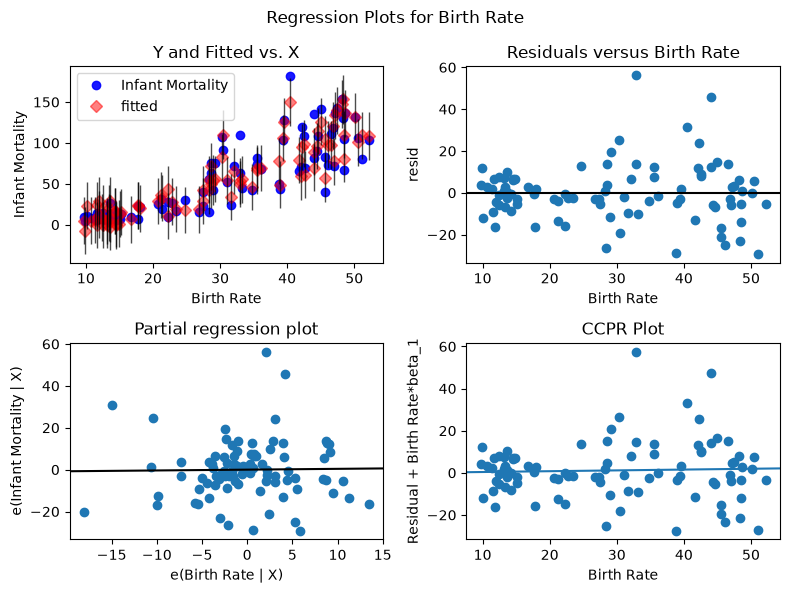

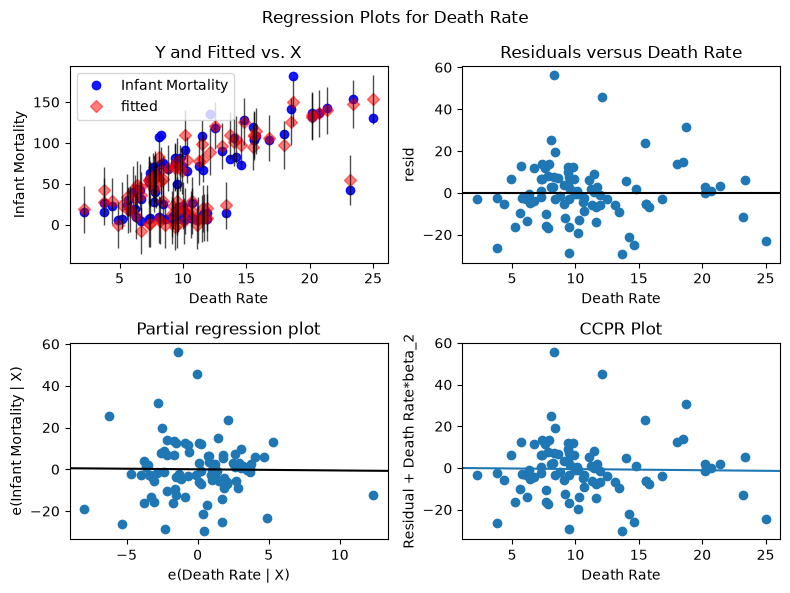

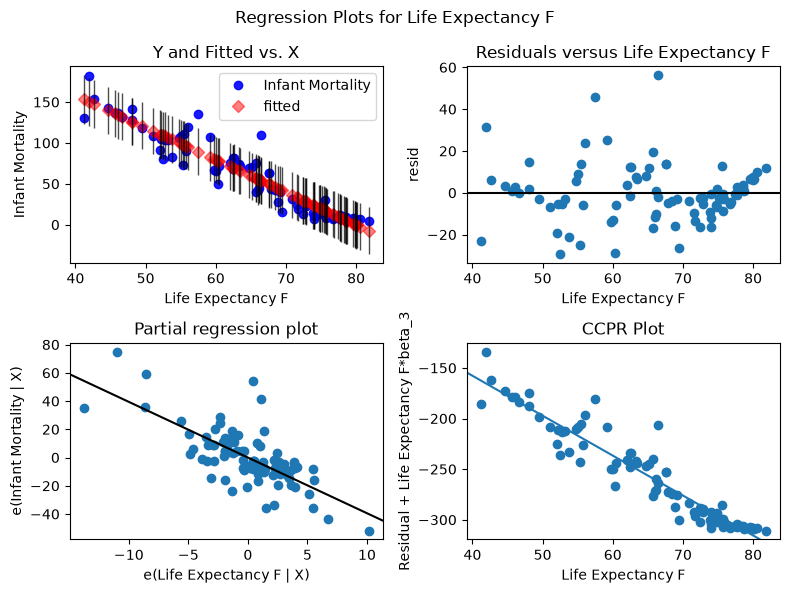

In [18]:
# Use a residual plot as a diagnostic check.
# This helps you see whether the model is behaving reasonably across the range of values.
for feature in reduced_features:
    fig = plt.figure(figsize=(8, 6))
    sm.graphics.plot_regress_exog(reduced_result, feature, fig=fig)
    plt.tight_layout()
    plt.show()


### Interpretation questions

- Does the reduced model appear to fit the data well?
- Are the residuals roughly centered around zero?
- Are there any obvious patterns or outliers?
- Does any feature look more influential than the others?

## 6. Symbolic regression and model discovery

This final section is included in the assignment because model discovery is a natural extension of the ideas you have already seen.

Instead of guessing a model form by hand, symbolic regression searches over many possible equations and keeps the ones that explain the data best. Many symbolic regression methods use genetic or evolutionary search, where candidate equations are repeatedly modified, compared, and refined over time. This is a good bridge to later topics in AutoML, where search and optimization are used to compare many candidate modeling strategies.

As part of this activity, read the StackGP repository and look through its documentation before trying any installation or examples:

https://github.com/hoolagans/StackGP

This is a good example of a scientific software repository: it is written by an MSU faculty member in the CMSE department, includes installation instructions, and provides documentation that makes the project easier to understand and reproduce. The point here is not simply to install a package; it is to see how a research software project is organized and communicated.

This does not replace human judgment. It is a powerful exploratory tool, but it still requires domain knowledge, interpretation, and careful validation.

In [19]:
# Optional extension if you want to explore symbolic regression.
# Before installing anything, read the project documentation.
# Example repo: https://github.com/hoolagans/StackGP
# This is a good example of a scientific software repository.
# Many symbolic regression methods use genetic or evolutionary search,
# which we will revisit later when we discuss AutoML.
#
# You do not need to run this section in full. It is mostly a conceptual extension.
# You may use StackGP if installed, or simply treat this as a reading exercise.
# Example idea:
# pip install StackGP

# Put your code here if you choose to explore it.


### Discussion prompt

In 4 to 6 sentences, discuss what automated model discovery did well and where human judgment still matters.

Consider questions such as:

- Did symbolic regression find a concise, interpretable equation?
- Was the result easier or harder to explain than a linear model?
- How does genetic search differ from fitting a fixed model form?
- What risks or limitations still remain?

# PUT YOUR GROUP ANSWERS HERE

- Data cleaning choice:
- Full model summary notes:
- Reduced model comparison:
- Diagnostic interpretation:
- Symbolic regression reflection:

## 7. Final reflection

Write a short reflection in your project repository as part of the final paper or project notes.

Your reflection should address:

- what you learned about analytical modeling,
- which methods or tools were most useful,
- how this work connects to your own project,
- whether you plan to adopt any of these ideas in future work.

This reflection is part of the required assignment and should be submitted with the rest of your project work.